# Backtest: Pure ITSM (PITSM) Strategy

**Research basis:** Intraday Time-Series Momentum (ITSM) in equity index futures  
(Notre Dame / Birmingham / AQR gamma-hedging study, 16+ developed markets, 60+ futures)

**Signal:** `r_open = log(close[10:00] / open[9:30])` — enter at 10:00 in the direction of first-30-min return  
**Exit:** time-based at 15:30 (matches ITSM literature spec)  
**Stop:** ATR-based (regime-adaptive — no fixed SL/TP to overfit)  

**CSCV learnings applied:**
- Removed fixed SL/TP (primary PBO driver in ORB v4/v5: 70-84pp spread)
- Removed EMA/RSI (0pp CSCV spread — irrelevant)
- Removed OR breakout (48pp CSCV spread)

**4 variants compared:**
1. PITSM default: 30-min window, ATR×2 stop
2. PITSM threshold: only trade when |r_open| > 0.001 (0.1%)
3. PITSM tight stop: ATR×1.5
4. PITSM wide stop: ATR×3.0

In [1]:
import asyncio
asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

In [2]:
import os, sys, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

THIS_DIR     = os.path.dirname(os.path.abspath('__file__'))
PROJECT_ROOT = os.path.abspath(os.path.join(THIS_DIR, '..', '..'))
NOTEBOOK_DIR = os.path.join(PROJECT_ROOT, 'notebooks', 'ORB_ITSM')

for p in [PROJECT_ROOT, NOTEBOOK_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)

from data_fetch import fetch_data
from strategy_pitsm import run_backtest, INITIAL_EQUITY

OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

SP500_SHARPE = 0.6
SP500_MAXDD  = 55.0
SP500_RETURN = 170.0

print('Setup complete.')

Setup complete.


## Load Data

In [3]:
df = fetch_data(refresh=False)
print(f'Bars loaded : {len(df):,}')
print(f'Date range  : {df.index[0].date()} to {df.index[-1].date()}')

[data_fetch] Loading cached data from C:\Users\kunpa\Downloads\Projects\Futures_v2\data\NQ_5m.csv ...


[data_fetch] Loaded 222,295 rows (2014-12-19 -> 2026-03-17)
Bars loaded : 222,295
Date range  : 2014-12-19 to 2026-03-17


## Run 4 Variants

In [4]:
# V1: default (30-min window, no threshold, ATR x2)
t1, eq1 = run_backtest(df)

# V2: signal threshold (only trade when |r_open| > 0.1%)
t2, eq2 = run_backtest(df, itsm_threshold=0.001)

# V3: tight ATR stop (1.5x)
t3, eq3 = run_backtest(df, atr_stop_mult=1.5)

# V4: wide ATR stop (3.0x)
t4, eq4 = run_backtest(df, atr_stop_mult=3.0)

print(f'V1 Default      : {len(t1):>4} trades')
print(f'V2 Threshold    : {len(t2):>4} trades')
print(f'V3 Tight stop   : {len(t3):>4} trades')
print(f'V4 Wide stop    : {len(t4):>4} trades')

V1 Default      : 2894 trades
V2 Threshold    : 2234 trades
V3 Tight stop   : 2894 trades
V4 Wide stop    : 2894 trades


## Performance Metrics

In [5]:
def compute_metrics(trades, equity, label=''):
    if trades.empty:
        return {}
    total    = len(trades)
    wins     = (trades['pnl'] > 0).sum()
    win_rate = wins / total * 100

    days_traded     = trades['date'].nunique()
    trades_per_year = (total / max(days_traded, 1)) * 252
    mean_pnl        = trades['pnl'].mean()
    std_pnl         = trades['pnl'].std(ddof=1)
    sharpe = (mean_pnl / std_pnl) * math.sqrt(trades_per_year) if std_pnl else float('nan')

    running_peak = equity.cummax()
    dd_series    = (equity - running_peak) / running_peak * 100
    max_dd       = abs(dd_series.min())

    net_pnl      = trades['pnl'].sum()
    total_return = (equity.iloc[-1] - INITIAL_EQUITY) / INITIAL_EQUITY * 100

    gross_wins   = trades.loc[trades['pnl'] > 0, 'pnl'].sum()
    gross_losses = abs(trades.loc[trades['pnl'] < 0, 'pnl'].sum())
    pf = gross_wins / gross_losses if gross_losses > 0 else float('inf')

    exit_sl  = (trades['exit_reason'] == 'SL').mean() * 100
    exit_time = (trades['exit_reason'] == 'TIME').mean() * 100

    return {
        'Trades':        total,
        'Win Rate':      f'{win_rate:.1f}%',
        'Sharpe':        f'{sharpe:.3f}',
        'Max Drawdown':  f'{max_dd:.1f}%',
        'Net P&L':       f'${net_pnl:,.0f}',
        'Total Return':  f'{total_return:.1f}%',
        'Profit Factor': f'{pf:.2f}',
        'Exit: SL':      f'{exit_sl:.0f}%',
        'Exit: TIME':    f'{exit_time:.0f}%',
    }

m1, m2, m3, m4 = [
    compute_metrics(t, e) for t, e in [(t1,eq1),(t2,eq2),(t3,eq3),(t4,eq4)]
]

sp500_row = {
    'Trades': '-', 'Win Rate': '-',
    'Sharpe': str(SP500_SHARPE), 'Max Drawdown': f'{SP500_MAXDD}%',
    'Net P&L': '-', 'Total Return': f'{SP500_RETURN}%',
    'Profit Factor': '-', 'Exit: SL': '-', 'Exit: TIME': '-',
}

summary = pd.DataFrame({
    'V1 Default':    m1,
    'V2 Threshold':  m2,
    'V3 Tight stop': m3,
    'V4 Wide stop':  m4,
    'S&P 500':       sp500_row,
}).T

print(summary.to_string())

              Trades Win Rate Sharpe Max Drawdown  Net P&L Total Return Profit Factor Exit: SL Exit: TIME
V1 Default      2894    51.9%  0.317        18.8%  $14,344        28.7%          1.06       1%        96%
V2 Threshold    2234    52.5%  0.501        16.1%  $18,284        36.6%          1.10       1%        97%
V3 Tight stop   2894    51.9%  0.339        19.0%  $15,834        31.7%          1.06       2%        94%
V4 Wide stop    2894    51.9%  0.364        17.3%  $16,092        32.2%          1.08       0%        97%
S&P 500            -        -    0.6        55.0%        -       170.0%             -        -          -


## Equity Curves

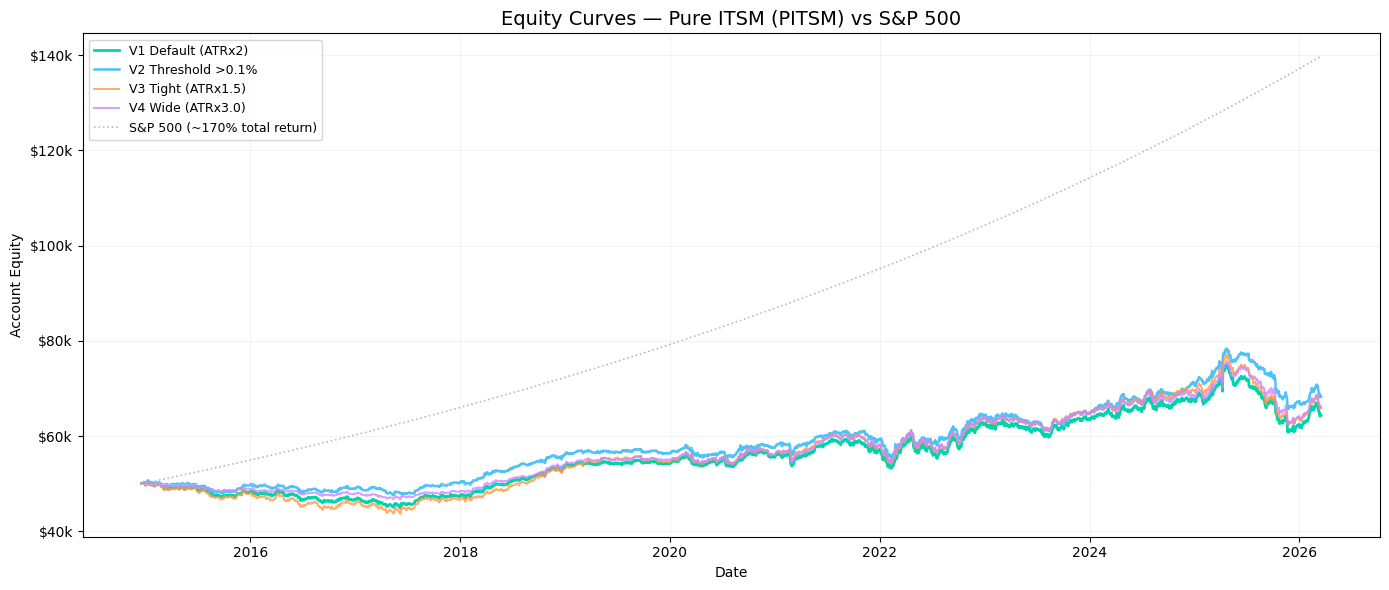

In [6]:
import re
def get_float(s):
    m = re.search(r'[-\d.]+', str(s))
    return float(m.group()) if m else float('nan')

start = min(eq1.index[0], eq2.index[0])
end   = max(eq1.index[-1], eq2.index[-1])
years = (end - start).days / 365.25
cagr_sp500 = (1 + SP500_RETURN / 100) ** (1 / years) - 1 if years > 0 else 0
biz_days   = pd.bdate_range(start, end)
daily_ret  = (1 + cagr_sp500) ** (1 / 252) - 1
sp500_eq   = pd.Series(
    INITIAL_EQUITY * (1 + daily_ret) ** np.arange(len(biz_days)),
    index=biz_days, name='S&P 500'
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(eq1.index, eq1.values, color='#00d4aa', lw=2.0, label='V1 Default (ATRx2)')
ax.plot(eq2.index, eq2.values, color='#4fc3f7', lw=1.8, label='V2 Threshold >0.1%')
ax.plot(eq3.index, eq3.values, color='#ff9944', lw=1.4, label='V3 Tight (ATRx1.5)', alpha=0.8)
ax.plot(eq4.index, eq4.values, color='#cc88ff', lw=1.4, label='V4 Wide (ATRx3.0)', alpha=0.8)
ax.plot(sp500_eq.index, sp500_eq.values, color='#aaaaaa', lw=1.2, linestyle=':',
        label=f'S&P 500 (~{SP500_RETURN:.0f}% total return)', alpha=0.8)
ax.axhline(INITIAL_EQUITY, color='white', lw=0.6, linestyle='--', alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_title('Equity Curves — Pure ITSM (PITSM) vs S&P 500', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Account Equity')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.15)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'pitsm_equity_curves.png'), dpi=150)
plt.show()

## Sharpe / Drawdown / Return vs S&P 500

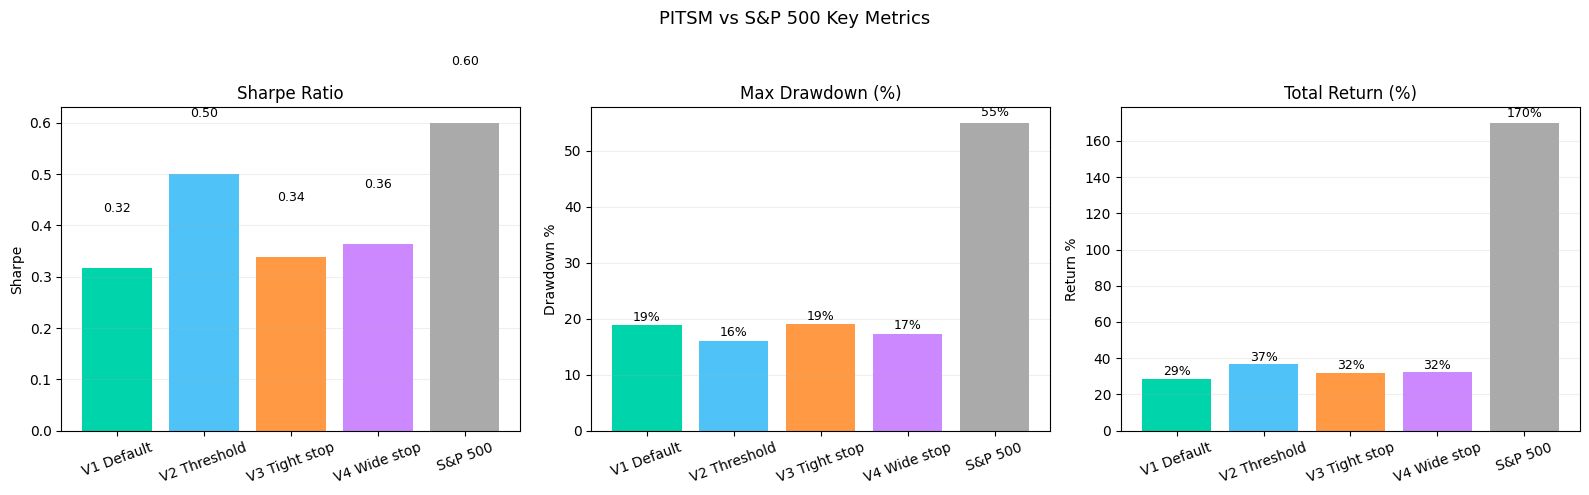

In [7]:
variant_labels  = ['V1 Default', 'V2 Threshold', 'V3 Tight stop', 'V4 Wide stop', 'S&P 500']
variant_metrics = [m1, m2, m3, m4, sp500_row]
var_colors      = ['#00d4aa', '#4fc3f7', '#ff9944', '#cc88ff', '#aaaaaa']

sharpes = [get_float(m.get('Sharpe', 0))      for m in variant_metrics]
maxdds  = [get_float(m.get('Max Drawdown', 0)) for m in variant_metrics]
returns = [get_float(m.get('Total Return', 0)) for m in variant_metrics]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, vals, title, ylabel in [
    (axes[0], sharpes, 'Sharpe Ratio',     'Sharpe'),
    (axes[1], maxdds,  'Max Drawdown (%)', 'Drawdown %'),
    (axes[2], returns, 'Total Return (%)', 'Return %'),
]:
    bars = ax.bar(variant_labels, vals, color=var_colors)
    for b, v in zip(bars, vals):
        if v == v:
            ax.text(b.get_x() + b.get_width()/2, v + abs(v)*0.01 + 0.1,
                    f'{v:.2f}' if title == 'Sharpe Ratio' else f'{v:.0f}%',
                    ha='center', va='bottom', fontsize=9)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.2)
fig.suptitle('PITSM vs S&P 500 Key Metrics', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'pitsm_metrics.png'), dpi=150)
plt.show()

## ATR Distribution & Position Sizing

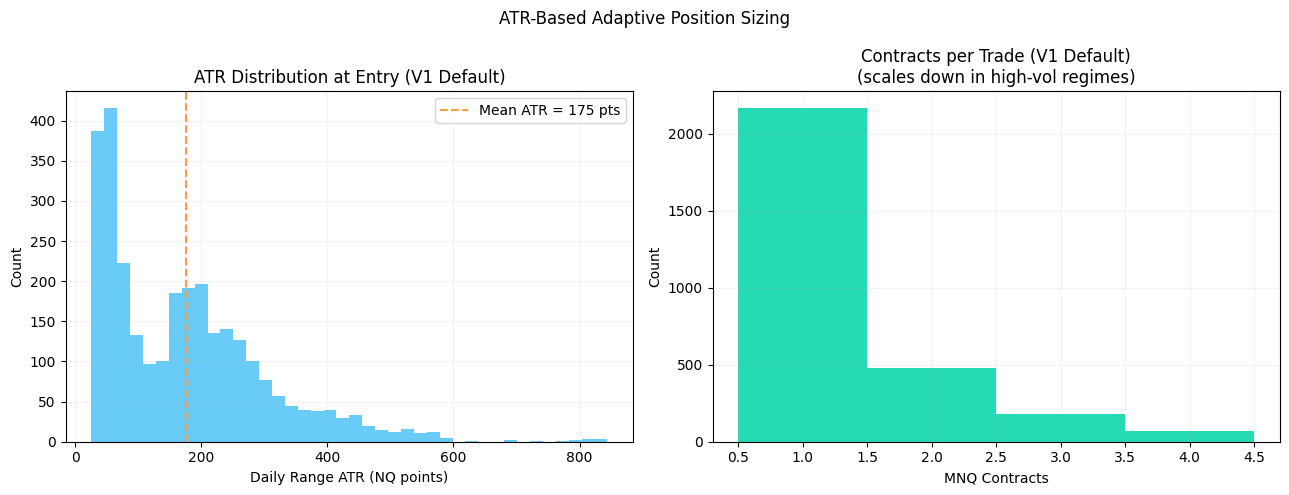

In [8]:
if not t1.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    ax.hist(t1['atr'], bins=40, color='#4fc3f7', edgecolor='none', alpha=0.85)
    ax.axvline(t1['atr'].mean(), color='#ff9944', lw=1.5, linestyle='--',
               label=f'Mean ATR = {t1["atr"].mean():.0f} pts')
    ax.set_title('ATR Distribution at Entry (V1 Default)')
    ax.set_xlabel('Daily Range ATR (NQ points)')
    ax.set_ylabel('Count')
    ax.legend()
    ax.grid(True, alpha=0.15)

    ax = axes[1]
    ax.hist(t1['contracts'], bins=range(1, t1['contracts'].max()+2),
            color='#00d4aa', edgecolor='none', alpha=0.85, align='left')
    ax.set_title('Contracts per Trade (V1 Default)\n(scales down in high-vol regimes)')
    ax.set_xlabel('MNQ Contracts')
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.15)

    fig.suptitle('ATR-Based Adaptive Position Sizing', fontsize=12)
    fig.tight_layout()
    plt.show()

## Summary

In [9]:
print('=' * 65)
print(' Pure ITSM (PITSM) Backtest Summary')
print('=' * 65)

for label, trades, m in [
    ('V1 Default     ', t1, m1),
    ('V2 Threshold   ', t2, m2),
    ('V3 Tight stop  ', t3, m3),
    ('V4 Wide stop   ', t4, m4),
]:
    wr     = get_float(m.get('Win Rate', 0))
    sharpe = get_float(m.get('Sharpe', 0))
    ret    = get_float(m.get('Total Return', 0))
    mdd    = get_float(m.get('Max Drawdown', 0))
    pnl    = m.get('Net P&L', '$0')
    sr_flag = 'PASS' if sharpe > 1.0 else ('OK' if sharpe > 0.6 else 'FAIL')
    dd_flag = 'PASS' if mdd < 10.0 else ('OK' if mdd < 20.0 else 'FAIL')
    print(f'\n {label}')
    print(f'   Trades       : {len(trades)}')
    print(f'   Win Rate     : {wr:.1f}%')
    print(f'   Sharpe       : {sharpe:.3f}  [{sr_flag}] (target > 1.0)')
    print(f'   Max Drawdown : {mdd:.1f}%   [{dd_flag}] (target < 10%)')
    print(f'   Total Return : {ret:.1f}%')
    print(f'   Net P&L      : {pnl}')

print()
print('S&P 500 benchmark: Sharpe ~0.6 | Max DD ~55% | Return ~170%')
print('=' * 65)

 Pure ITSM (PITSM) Backtest Summary

 V1 Default     
   Trades       : 2894
   Win Rate     : 51.9%
   Sharpe       : 0.317  [FAIL] (target > 1.0)
   Max Drawdown : 18.8%   [OK] (target < 10%)
   Total Return : 28.7%
   Net P&L      : $14,344

 V2 Threshold   
   Trades       : 2234
   Win Rate     : 52.5%
   Sharpe       : 0.501  [FAIL] (target > 1.0)
   Max Drawdown : 16.1%   [OK] (target < 10%)
   Total Return : 36.6%
   Net P&L      : $18,284

 V3 Tight stop  
   Trades       : 2894
   Win Rate     : 51.9%
   Sharpe       : 0.339  [FAIL] (target > 1.0)
   Max Drawdown : 19.0%   [OK] (target < 10%)
   Total Return : 31.7%
   Net P&L      : $15,834

 V4 Wide stop   
   Trades       : 2894
   Win Rate     : 51.9%
   Sharpe       : 0.364  [FAIL] (target > 1.0)
   Max Drawdown : 17.3%   [OK] (target < 10%)
   Total Return : 32.2%
   Net P&L      : $16,092

S&P 500 benchmark: Sharpe ~0.6 | Max DD ~55% | Return ~170%
